In [2]:
import pandas as pd 
import numpy as np 
import sklearn as sk
import seaborn as sns
import os 
import pandas as pd
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
from sklearn.preprocessing import MaxAbsScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report
import os
os.environ["OMP_NUM_THREADS"] = "2"
os.environ["OPENBLAS_NUM_THREADS"] = "2"
os.environ["MKL_NUM_THREADS"] = "2"

In [3]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
train_id=['CRC1502','CRC1620','CRC1139']
tratt_cercato=['cetux','CTX72h']
train=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in train_id and trattamento in tratt_cercato:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        train=pd.concat([train,data])

filtered_annotated_saver_ribomito_CRC1502_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC1139_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC1620_cetux_1_log2_pc1_cpm.csv


In [4]:
from func_NT_cetux import *
df=train
df_clean, dup = strip_prefix_from_genes(df, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")

In [5]:
hvg=pd.read_csv('bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/highly_variable_genes.csv',header=0,index_col=False)
to_keep=list(hvg['gene'])
to_keep = to_keep + ['sample', 'cell_id', 'trattamento']

In [6]:
df_clean = df_clean.loc[:,to_keep]

In [7]:
clu_path='bbknn_cetux_KRAS/npcs=20__nwb=3__trim=None__res=0.3/obs_data_with_umap.csv'
meta_data=pd.read_csv(clu_path,header=0)

In [8]:
df_clean['uid']=df_clean['sample']+df_clean['trattamento']+'|'+df_clean['cell_id']+'|'+df_clean['trattamento']

In [9]:
label=meta_data.loc[:,['uid','leiden_r0.3']]
label=label.rename(columns={'leiden_r0.3':'cluster'})

In [10]:
merged_df = df_clean.merge(label, on='uid', how='inner')

In [11]:
meta_cols = ['uid','sample','cell_id','trattamento','cluster']
feature_cols = [c for c in merged_df.columns if c not in meta_cols]  # geni/features numeriche

X = merged_df[feature_cols].copy()
y = merged_df['cluster'].copy()

# usa uid come index
X.index = merged_df['uid']
y.index = merged_df['uid']

# (OPZIONALE, ma spesso consigliato per scRNA-seq)
# split per campione per evitare
groups = merged_df.set_index('uid')['sample']  
use_group_split = False  # metti True se vuoi split per sample

if use_group_split:
    gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
    train_idx, test_idx = next(gss.split(X, y, groups=groups))
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
else:
    # split classico ma STRATIFICATO (preserva proporzioni dei cluster)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

In [12]:
import pandas as pd

pd.concat([
    y_train.value_counts(normalize=True).rename('train'),
    y_test.value_counts(normalize=True).rename('test')
], axis=1).fillna(0).round(3)

train_uids = X_train.index
test_uids = X_test.index

sample_map = merged_df.set_index('uid')['sample']


pd.concat([
    sample_map.loc[train_uids].value_counts(normalize=True).rename('train'),
    sample_map.loc[test_uids].value_counts(normalize=True).rename('test')
], axis=1).fillna(0).round(3)

train_meta = merged_df.set_index('uid').loc[train_uids, ['sample', 'cluster']]
test_meta = merged_df.set_index('uid').loc[test_uids, ['sample', 'cluster']]

print("\nTrain:")
display(pd.crosstab(train_meta['sample'], train_meta['cluster'], normalize='index').round(2))

print("\nTest:")
display(pd.crosstab(test_meta['sample'], test_meta['cluster'], normalize='index').round(2))



Train:


cluster,0,1,2,3,4,5,6
sample,,,,,,,
CRC1139,0.20,0.18,0.29,0.12,0.02,0.16,0.02
CRC1502,0.25,0.14,0.16,0.15,0.12,0.09,0.08
CRC1620,0.22,0.24,0.10,0.15,0.19,0.10,0.01



Test:


cluster,0,1,2,3,4,5,6
sample,,,,,,,
CRC1139,0.23,0.15,0.31,0.09,0.01,0.18,0.03
CRC1502,0.25,0.12,0.17,0.17,0.11,0.09,0.08
CRC1620,0.21,0.27,0.08,0.14,0.20,0.10,0.01


In [13]:
scaler = MaxAbsScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [14]:
rf = RandomForestClassifier(random_state=42, n_jobs=3,max_depth= None, max_features= 'log2', min_samples_split= 2, n_estimators= 300)
rf.fit(X_train_scaled,y_train)
pred=rf.predict(X_test_scaled)
print("\n--- Random Forest Test ---")
print(classification_report(y_test, pred))


--- Random Forest Test ---
              precision    recall  f1-score   support

           0       0.94      0.94      0.94       598
           1       0.93      0.95      0.94       490
           2       0.93      0.96      0.94       399
           3       0.86      0.88      0.87       378
           4       0.97      0.96      0.97       340
           5       0.92      0.87      0.90       281
           6       0.95      0.81      0.88       104

    accuracy                           0.93      2590
   macro avg       0.93      0.91      0.92      2590
weighted avg       0.93      0.93      0.93      2590



In [15]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
test_id=['CRC0322','CRC0542','CRC0327']
tratt_cercato=['cetux','CTX72h']
test=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in test_id and trattamento in tratt_cercato:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        test=pd.concat([test,data])

filtered_annotated_saver_ribomito_CRC0322_cetux_1_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC0327_cetux_2_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC0542_CTX72h_1_log2_pc1_cpm.csv


In [16]:
from func_NT_cetux import *
dt=test
df_clean_dt, dup = strip_prefix_from_genes(dt, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")

In [17]:
df_clean_dt = df_clean_dt.loc[:,to_keep]

In [18]:
df_clean_dt['uid']=df_clean_dt['sample']+df_clean_dt['trattamento']+'|'+df_clean_dt['cell_id']+'|'+df_clean_dt['trattamento']

In [19]:
df_clean_dt.head()

,TNMD,C1orf112,CFTR,CYP26B1,ALS2,ARHGAP33,PDK4,PRSS22,MCUB,REXO5,...,H3C7,RDM1,H2AC4,C17orf78,H2BC10,H2AC17,sample,cell_id,trattamento,uid
0,1.290913,2.075592,7.156117,2.501312,3.013173,1.290913,3.275151,2.580994,2.416971,2.327390,...,0.0,0.716363,0.215068,0.215068,0.0,0.215068,CRC0322,AAACCCACACACCAGC.1,cetux,CRC0322cetux|AAACCCACACACCAGC.1|cetux
1,1.236142,2.004544,6.242467,2.503236,2.683182,1.409765,3.283417,2.749314,2.424464,1.489322,...,0.0,0.537935,0.202425,0.202425,0.0,0.202425,CRC0322,AAACCCACACTGGCCA.1,cetux,CRC0322cetux|AAACCCACACTGGCCA.1|cetux
2,1.181180,2.220954,6.132490,2.423915,3.954869,1.878172,3.196783,4.599302,1.932415,0.508470,...,0.0,0.190105,0.190105,0.190105,0.0,0.190105,CRC0322,AAACCCAGTGTCTTCC.1,cetux,CRC0322cetux|AAACCCAGTGTCTTCC.1|cetux
3,1.116606,2.305453,6.031352,2.124012,3.614179,1.116606,2.892585,2.347459,2.171556,1.971188,...,0.0,0.663738,0.196664,0.196664,0.0,0.196664,CRC0322,AAACGAATCGAAGCCC.1,cetux,CRC0322cetux|AAACGAATCGAAGCCC.1|cetux
4,1.146387,2.295855,5.888797,2.255684,3.856419,1.312244,3.026213,5.387413,3.559180,1.055713,...,0.0,0.182493,0.182493,0.182493,0.0,0.182493,CRC0322,AAACGCTGTCTGCATA.1,cetux,CRC0322cetux|AAACGCTGTCTGCATA.1|cetux


In [20]:
df_clean_dt.index=df_clean_dt['uid']

In [21]:
meta_cols_dt = ['uid','sample','cell_id','trattamento']
feature_cols = [c for c in df_clean_dt.columns if c not in meta_cols_dt]
X_dt = df_clean_dt[feature_cols].copy()


In [22]:
X_dt_sclaed = scaler.transform(X_dt)

In [23]:
probs = rf.predict_proba(X_dt_sclaed)
pred = rf.predict(X_dt_sclaed)


In [24]:
import numpy as np

max_prob = probs.max(axis=1)
import pandas as pd

df_plot = pd.DataFrame({
    "pred_class": pred,
    "prob_winner": max_prob
})


In [25]:
df_plot['sample']=df_clean_dt['sample'].values
df_plot['trattamento']=df_clean_dt['trattamento'].values

In [26]:
df_plot

,pred_class,prob_winner,sample,trattamento
0,0,0.560000,CRC0322,cetux
1,0,0.563333,CRC0322,cetux
2,0,0.600000,CRC0322,cetux
3,0,0.563333,CRC0322,cetux
4,0,0.476667,CRC0322,cetux
...,...,...,...,...
8432,4,0.390000,CRC0542,CTX72h
8433,4,0.420000,CRC0542,CTX72h
8434,0,0.473333,CRC0542,CTX72h
8435,0,0.410000,CRC0542,CTX72h


<Axes: xlabel='pred_class', ylabel='prob_winner'>

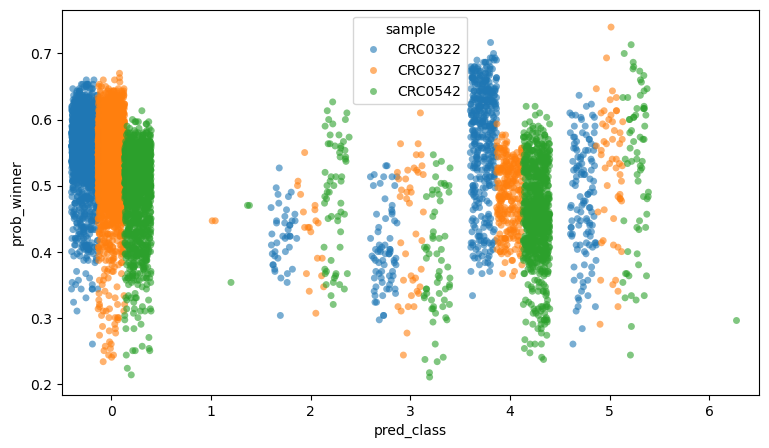

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(9,5))
sns.stripplot(
    data=df_plot,
    x="pred_class",
    y="prob_winner",
    hue="sample",
    dodge=True,     
    jitter=0.4,
    alpha=0.6
)



In [29]:
from scipy.stats import entropy
import numpy as np

ent = entropy(probs, base=2)   # entropia per ogni riga


In [30]:
eps = 1e-12  
ent = -(probs * np.log2(probs + eps)).sum(axis=1)


In [31]:
df_plot['entropia']=ent

<Axes: xlabel='pred_class', ylabel='entropia'>

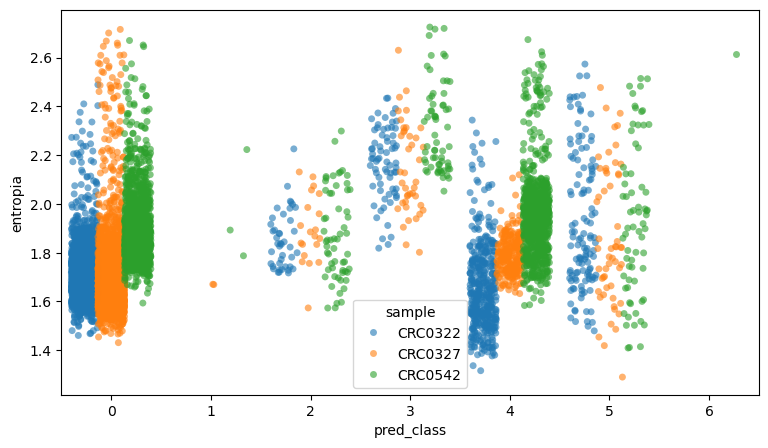

In [32]:
plt.figure(figsize=(9,5))
sns.stripplot(
    data=df_plot,
    x="pred_class",
    y="entropia",
    hue="sample",
    dodge=True,     
    jitter=0.4,
    alpha=0.6
)

<Axes: >

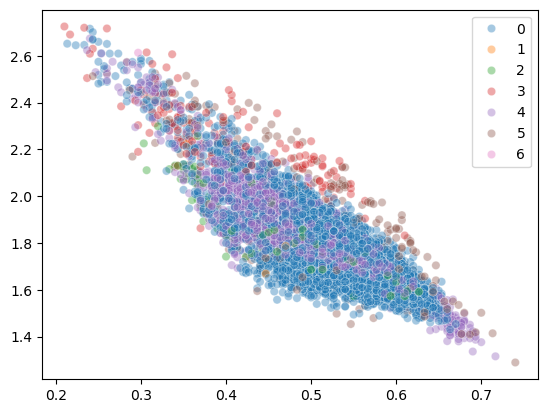

In [33]:
sns.scatterplot(
    x=max_prob,
    y=ent,
    hue=pred,
    palette="tab10",
    alpha=0.4
)



<Axes: >

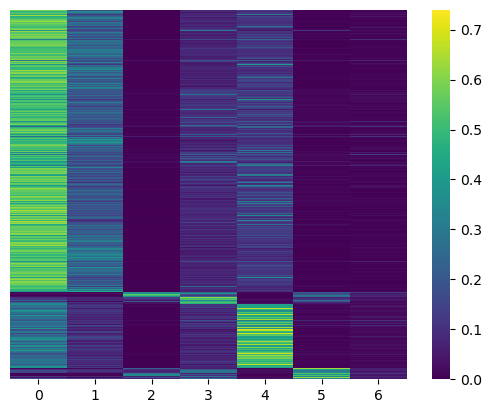

In [34]:
order = np.argsort(pred)  # o per entropia
sns.heatmap(probs[order], cmap="viridis", xticklabels=True, yticklabels=False)




In [35]:
import numpy as np

bins = np.linspace(0, 1, 9)  # 8 bin
probs_binned = np.digitize(probs, bins) - 1


0.74


/tmp/ipykernel_1788778/3106650859.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("rainbow", num_bins)


array([0.   , 0.074, 0.148, 0.222, 0.296, 0.37 , 0.444, 0.518, 0.592,
       0.666, 0.74 ])

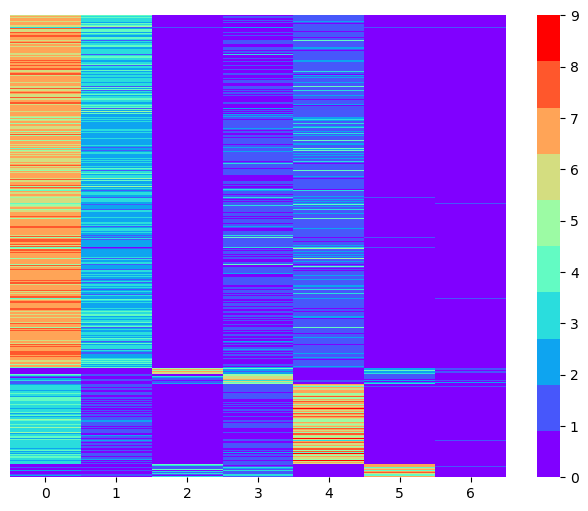

In [36]:
pmax = probs.max()
print(pmax)
num_bins = 10
bins = np.linspace(0, pmax, num_bins + 1)
probs_binned = np.digitize(probs, bins) - 1
cmap = plt.cm.get_cmap("rainbow", num_bins)
plt.figure(figsize=(8,6))
ax = sns.heatmap(
    probs_binned[order],
    cmap=cmap,
    xticklabels=True,
    yticklabels=False,
    vmin=0,
    vmax=num_bins - 1,
    cbar=True
)
bins

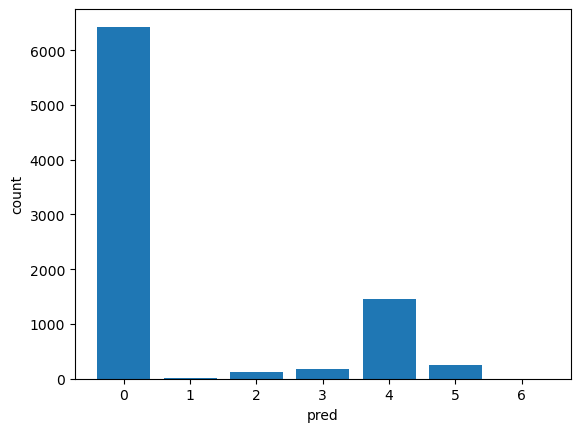

In [37]:
import numpy as np
import matplotlib.pyplot as plt

unique, counts = np.unique(pred, return_counts=True)

plt.bar(unique, counts, align='center')
plt.xticks(unique) 
plt.xlabel("pred")
plt.ylabel("count")

plt.show()


In [38]:
pred_series = pd.Series(pred, index=df_clean_dt.index, name="pred")

df_pred = df_clean_dt[meta_cols_dt].copy()
df_pred["pred"] = pred_series

df_pred.head()

,uid,sample,cell_id,trattamento,pred
uid,,,,,
CRC0322cetux|AAACCCACACACCAGC.1|cetux,CRC0322cetux|AAACCCACACACCAGC.1|cetux,CRC0322,AAACCCACACACCAGC.1,cetux,0
CRC0322cetux|AAACCCACACTGGCCA.1|cetux,CRC0322cetux|AAACCCACACTGGCCA.1|cetux,CRC0322,AAACCCACACTGGCCA.1,cetux,0
CRC0322cetux|AAACCCAGTGTCTTCC.1|cetux,CRC0322cetux|AAACCCAGTGTCTTCC.1|cetux,CRC0322,AAACCCAGTGTCTTCC.1,cetux,0
CRC0322cetux|AAACGAATCGAAGCCC.1|cetux,CRC0322cetux|AAACGAATCGAAGCCC.1|cetux,CRC0322,AAACGAATCGAAGCCC.1,cetux,0
CRC0322cetux|AAACGCTGTCTGCATA.1|cetux,CRC0322cetux|AAACGCTGTCTGCATA.1|cetux,CRC0322,AAACGCTGTCTGCATA.1,cetux,0


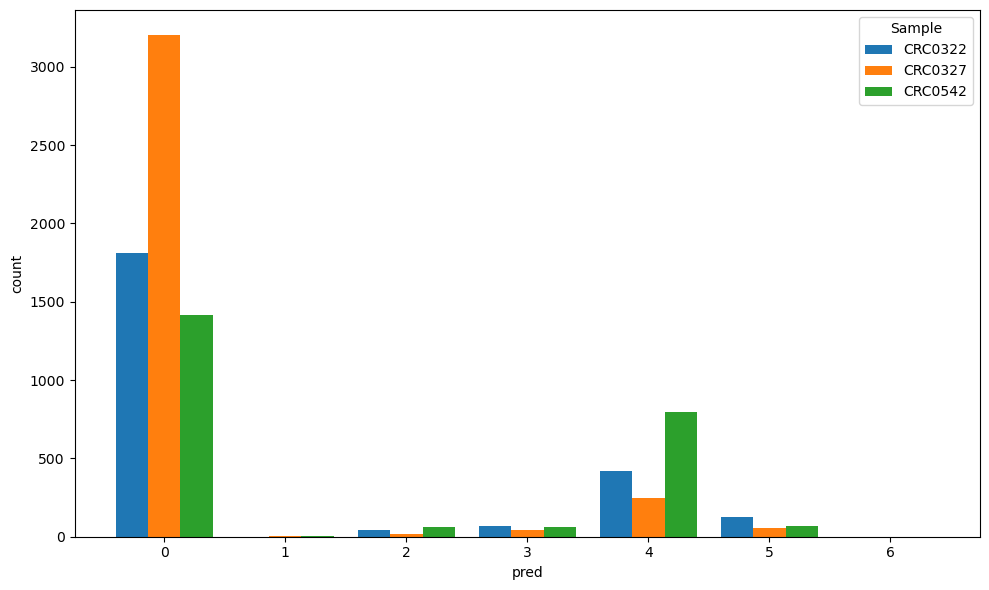

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ct = pd.crosstab(df_pred["pred"], df_pred["sample"])

labels = ct.index                 
samples = ct.columns              
n_samples = len(samples)

x = np.arange(len(labels))        
width = 0.8 / n_samples           

plt.figure(figsize=(10,6))

for i, s in enumerate(samples):
    plt.bar(
        x + i*width,
        ct[s],
        width,
        label=s
    )

plt.xticks(x + width*(n_samples-1)/2, labels)  
plt.xlabel("pred")
plt.ylabel("count")
plt.legend(title="Sample")
plt.tight_layout()
plt.show()



In [285]:
data_path='/mnt/cold2/snaketree/prj/PPH/local/share/data/saver_mat'
test_id=['CRC0322','CRC0542','CRC0327']
tratt_cercato=['NT','NT72h']
test_nt=pd.DataFrame()
for file in os.listdir(data_path):
    sample_name=str.split(file,sep='_')[4]
    trattamento=str.split(file,sep='_')[5]
    if sample_name in test_id and trattamento in tratt_cercato:
        print(file)
        data=pd.read_csv(os.path.join(data_path,file),header=0,index_col=0)
        data=data.T
        data['sample']=sample_name
        data['cell_id']=data.index
        data['trattamento']=trattamento
        data.reset_index(drop=True,inplace=True)
        test_nt=pd.concat([test_nt,data])

filtered_annotated_saver_ribomito_CRC0322_NT_1_3000_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC0327_NT_2_log2_pc1_cpm.csv
filtered_annotated_saver_ribomito_CRC0542_NT72h_1_log2_pc1_cpm.csv


In [286]:
from func_NT_cetux import *
nt=test_nt
df_clean_nt, dup = strip_prefix_from_genes(nt, meta_cols=("cell_id","sample","trattamento"), sep=":", on_duplicate="first")

In [287]:
df_clean_nt = df_clean_nt.loc[:,to_keep]
df_clean_nt['uid']=df_clean_nt['sample']+df_clean_nt['trattamento']+'|'+df_clean_nt['cell_id']+'|'+df_clean_nt['trattamento']
df_clean_nt.index=df_clean_nt['uid']
meta_cols_nt = ['uid','sample','cell_id','trattamento']
feature_cols = [c for c in df_clean_nt.columns if c not in meta_cols_dt]
X_nt = df_clean_nt[feature_cols].copy()


In [288]:
X_nt_sclaed = scaler.transform(X_nt)

In [289]:
probs_nt = rf.predict_proba(X_nt_sclaed)
pred_nt = rf.predict(X_nt_sclaed)

In [290]:
import numpy as np

max_prob = probs_nt.max(axis=1)
import pandas as pd

df_plot = pd.DataFrame({
    "pred_class": pred_nt,
    "prob_winner": max_prob
})

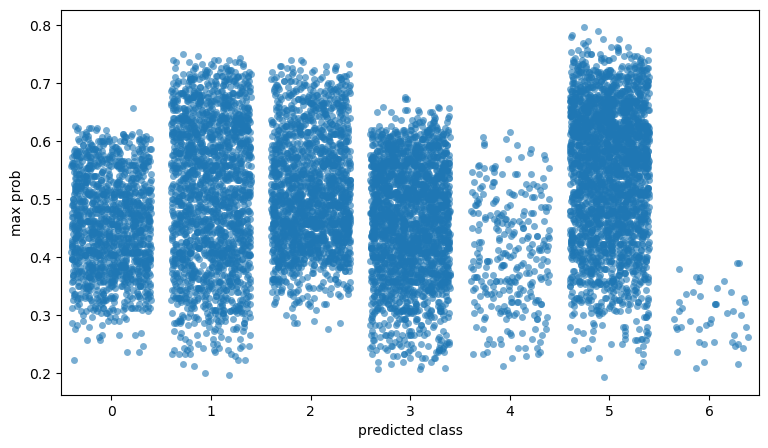

In [291]:
plt.figure(figsize=(9,5))
sns.stripplot(
    data=df_plot,
    x="pred_class",
    y="prob_winner",
    jitter=0.4,
    alpha=0.6
)
plt.ylabel("max prob")
plt.xlabel("predicted class")
plt.title("")
plt.show()


In [293]:
import numpy as np

bins = np.linspace(0, 1, 9)  # 8 bin
probs_binned = np.digitize(probs_nt, bins) - 1

In [294]:
order = np.argsort(pred_nt)  # o per entropia

0.7966666666666666


/tmp/ipykernel_199483/3335358626.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("rainbow", num_bins)


array([0.        , 0.07966667, 0.15933333, 0.239     , 0.31866667,
       0.39833333, 0.478     , 0.55766667, 0.63733333, 0.717     ,
       0.79666667])

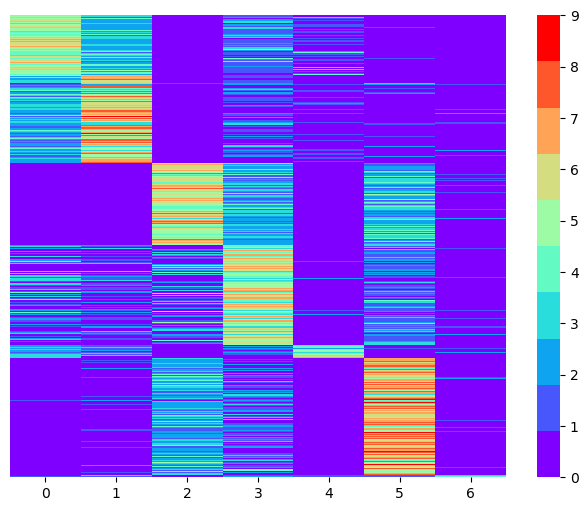

In [295]:
pmax = probs_nt.max()
print(pmax)
num_bins = 10
bins = np.linspace(0, pmax, num_bins + 1)
probs_binned = np.digitize(probs_nt, bins) - 1
cmap = plt.cm.get_cmap("rainbow", num_bins)
plt.figure(figsize=(8,6))
ax = sns.heatmap(
    probs_binned[order],
    cmap=cmap,
    xticklabels=True,
    yticklabels=False,
    vmin=0,
    vmax=num_bins - 1,
    cbar=True
)
bins

In [296]:
eps = 1e-12  
ent = -(probs_nt * np.log2(probs_nt + eps)).sum(axis=1)

<Axes: >

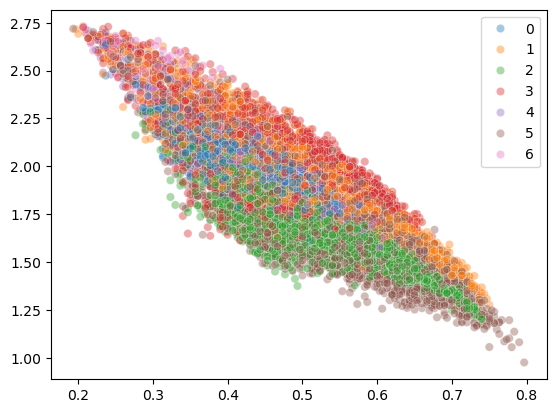

In [298]:
sns.scatterplot(
    x=max_prob,
    y=ent,
    hue=pred_nt,
    palette="tab10",
    alpha=0.4
)

In [148]:
pred_series_nt = pd.Series(pred_nt, index=df_clean_nt.index, name="pred")

df_pred_nt = df_clean_nt[meta_cols_nt].copy()
df_pred_nt["pred"] = pred_series_nt

df_pred_nt.head()

,uid,sample,cell_id,trattamento,pred
uid,,,,,
CRC0322NT|CATGGATGTGTGTGGA.1|NT,CRC0322NT|CATGGATGTGTGTGGA.1|NT,CRC0322,CATGGATGTGTGTGGA.1,NT,1
CRC0322NT|TAGAGTCAGTACTGTC.1|NT,CRC0322NT|TAGAGTCAGTACTGTC.1|NT,CRC0322,TAGAGTCAGTACTGTC.1,NT,5
CRC0322NT|AGGTAGGAGATGCAGC.1|NT,CRC0322NT|AGGTAGGAGATGCAGC.1|NT,CRC0322,AGGTAGGAGATGCAGC.1,NT,2
CRC0322NT|CATGCCTAGGTGCCTC.1|NT,CRC0322NT|CATGCCTAGGTGCCTC.1|NT,CRC0322,CATGCCTAGGTGCCTC.1,NT,5
CRC0322NT|TGAATGCAGAACCGCA.1|NT,CRC0322NT|TGAATGCAGAACCGCA.1|NT,CRC0322,TGAATGCAGAACCGCA.1,NT,1


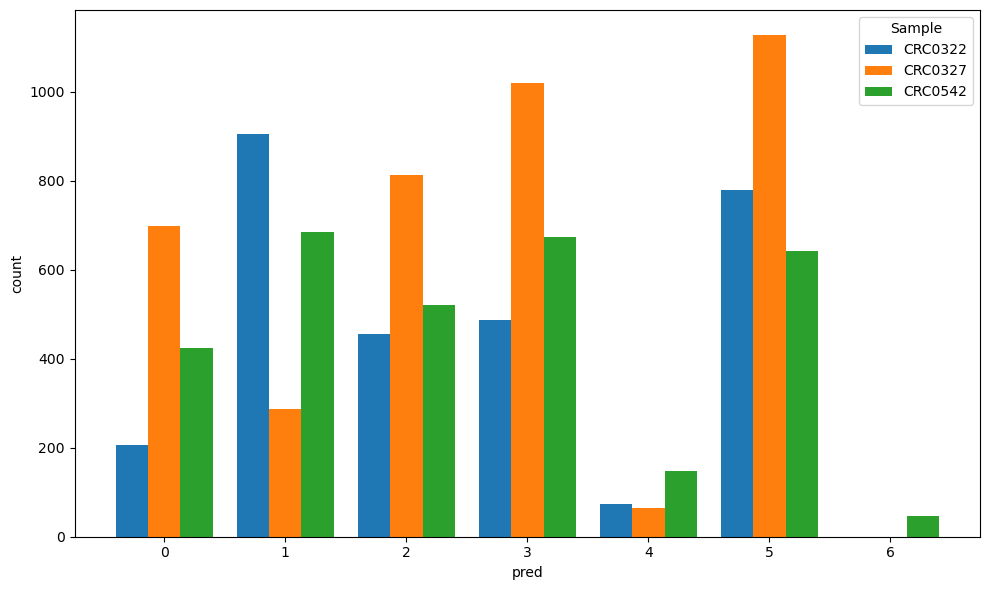

In [149]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


ct = pd.crosstab(df_pred_nt["pred"], df_pred_nt["sample"])

labels = ct.index                 
samples = ct.columns              
n_samples = len(samples)

x = np.arange(len(labels))        
width = 0.8 / n_samples           

plt.figure(figsize=(10,6))

for i, s in enumerate(samples):
    plt.bar(
        x + i*width,
        ct[s],
        width,
        label=s
    )

plt.xticks(x + width*(n_samples-1)/2, labels)  # centra le etichette
plt.xlabel("pred")
plt.ylabel("count")
plt.legend(title="Sample")
plt.tight_layout()
plt.show()

In [167]:
umap_cetux=pd.read_csv('bbknn_cetux_WT/npcs=20__nwb=3__trim=None__res=0.3/obs_data_with_umap.csv',header=0)
umap_cetux

,cell_id,sample,trattamento,uid,S_score,G2M_score,phase,leiden_r0.3,umap_1,umap_2
0,AAACCCACACACCAGC.1,CRC0322,cetux,CRC0322cetux|AAACCCACACACCAGC.1|cetux,-0.407178,-1.448555,G1,0,1.572304,2.750546
1,AAACCCACACTGGCCA.1,CRC0322,cetux,CRC0322cetux|AAACCCACACTGGCCA.1|cetux,-0.273874,-1.376480,G1,0,1.058293,3.157196
2,AAACCCAGTGTCTTCC.1,CRC0322,cetux,CRC0322cetux|AAACCCAGTGTCTTCC.1|cetux,-0.563277,-1.609875,G1,1,8.426912,5.219655
3,AAACGAATCGAAGCCC.1,CRC0322,cetux,CRC0322cetux|AAACGAATCGAAGCCC.1|cetux,-0.520543,-1.715717,G1,1,5.554079,2.337076
4,AAACGCTGTCTGCATA.1,CRC0322,cetux,CRC0322cetux|AAACGCTGTCTGCATA.1|cetux,-0.455233,-1.686754,G1,1,7.597211,1.367087
...,...,...,...,...,...,...,...,...,...,...
8432,TTTGATCCAGGTGAGT.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGATCCAGGTGAGT.1|CTX72h,-0.786528,-1.406275,G1,2,12.855942,0.912187
8433,TTTGGAGAGGCGAACT.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGGAGAGGCGAACT.1|CTX72h,-0.660726,-0.708616,G1,1,9.307500,2.426343
8434,TTTGGTTAGGATGCGT.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGGTTAGGATGCGT.1|CTX72h,-0.332309,-1.086393,G1,1,5.284249,1.097638
8435,TTTGGTTAGGGAACAA.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGGTTAGGGAACAA.1|CTX72h,-0.934003,-1.313689,G1,1,8.129117,2.215554


In [168]:
df_pred.reset_index(inplace=True,drop=True)
umap_cetux = umap_cetux.merge(df_pred[['uid', 'pred']], on='uid', how='inner')
umap_cetux

,cell_id,sample,trattamento,uid,S_score,G2M_score,phase,leiden_r0.3,umap_1,umap_2,pred
0,AAACCCACACACCAGC.1,CRC0322,cetux,CRC0322cetux|AAACCCACACACCAGC.1|cetux,-0.407178,-1.448555,G1,0,1.572304,2.750546,0
1,AAACCCACACTGGCCA.1,CRC0322,cetux,CRC0322cetux|AAACCCACACTGGCCA.1|cetux,-0.273874,-1.376480,G1,0,1.058293,3.157196,0
2,AAACCCAGTGTCTTCC.1,CRC0322,cetux,CRC0322cetux|AAACCCAGTGTCTTCC.1|cetux,-0.563277,-1.609875,G1,1,8.426912,5.219655,0
3,AAACGAATCGAAGCCC.1,CRC0322,cetux,CRC0322cetux|AAACGAATCGAAGCCC.1|cetux,-0.520543,-1.715717,G1,1,5.554079,2.337076,0
4,AAACGCTGTCTGCATA.1,CRC0322,cetux,CRC0322cetux|AAACGCTGTCTGCATA.1|cetux,-0.455233,-1.686754,G1,1,7.597211,1.367087,0
...,...,...,...,...,...,...,...,...,...,...,...
8432,TTTGATCCAGGTGAGT.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGATCCAGGTGAGT.1|CTX72h,-0.786528,-1.406275,G1,2,12.855942,0.912187,4
8433,TTTGGAGAGGCGAACT.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGGAGAGGCGAACT.1|CTX72h,-0.660726,-0.708616,G1,1,9.307500,2.426343,4
8434,TTTGGTTAGGATGCGT.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGGTTAGGATGCGT.1|CTX72h,-0.332309,-1.086393,G1,1,5.284249,1.097638,0
8435,TTTGGTTAGGGAACAA.1,CRC0542,CTX72h,CRC0542CTX72h|TTTGGTTAGGGAACAA.1|CTX72h,-0.934003,-1.313689,G1,1,8.129117,2.215554,0


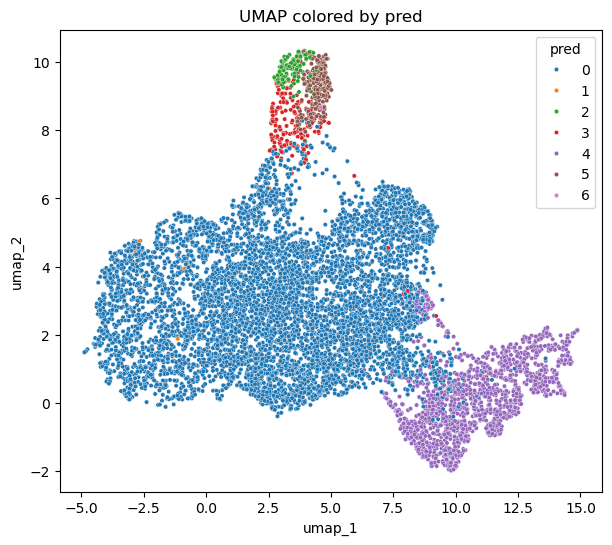

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=umap_cetux,
    x='umap_1',
    y='umap_2',
    hue='pred',
    s=10,
    palette='tab10'
)

plt.title('UMAP colored by pred')
plt.legend(title='pred')
plt.show()


In [171]:
umap_nt=pd.read_csv('bbknn_NT_WT/npcs=20__nwb=3__trim=None__res=0.3/obs_data_with_umap.csv',header=0)
umap_nt
umap_nt['uid']=umap_nt['sample']+umap_nt['trattamento']+'|'+umap_nt['cell_id']+'|'+umap_nt['trattamento']

In [172]:
df_pred_nt.reset_index(inplace=True,drop=True)
umap_nt = umap_nt.merge(df_pred_nt[['uid', 'pred']], on='uid', how='inner')
umap_nt

,cell_id,sample,uid,S_score,G2M_score,phase,leiden_r0.3,umap_1,umap_2,trattamento,pred
0,CATGGATGTGTGTGGA.1,CRC0322,CRC0322NT|CATGGATGTGTGTGGA.1|NT,-0.467580,0.129730,G2M,0,1.597879,-0.034175,NT,1
1,TAGAGTCAGTACTGTC.1,CRC0322,CRC0322NT|TAGAGTCAGTACTGTC.1|NT,0.738907,2.553020,G2M,2,9.460746,-0.163228,NT,5
2,AGGTAGGAGATGCAGC.1,CRC0322,CRC0322NT|AGGTAGGAGATGCAGC.1|NT,1.332186,1.433580,G2M,1,6.514751,0.144018,NT,2
3,CATGCCTAGGTGCCTC.1,CRC0322,CRC0322NT|CATGCCTAGGTGCCTC.1|NT,1.160565,2.647576,G2M,1,9.150382,-0.649170,NT,5
4,TGAATGCAGAACCGCA.1,CRC0322,CRC0322NT|TGAATGCAGAACCGCA.1|NT,-1.297974,-1.488375,G1,0,0.193494,2.310349,NT,1
...,...,...,...,...,...,...,...,...,...,...,...
6907,TTTGGTTCACAGTGTT.1,CRC0327,CRC0327NT|TTTGGTTCACAGTGTT.1|NT,0.453885,1.101653,G2M,2,9.177263,1.512235,NT,5
6908,TTTGGTTTCAGACCTA.1,CRC0327,CRC0327NT|TTTGGTTTCAGACCTA.1|NT,0.030248,0.604906,G2M,1,7.568267,1.598140,NT,5
6909,TTTGGTTTCAGCACCG.1,CRC0327,CRC0327NT|TTTGGTTTCAGCACCG.1|NT,1.837821,1.531459,S,5,11.770424,3.243360,NT,2
6910,TTTGGTTTCGGAAGGT.1,CRC0327,CRC0327NT|TTTGGTTTCGGAAGGT.1|NT,-0.126905,-0.765547,G1,3,4.464050,4.347102,NT,3


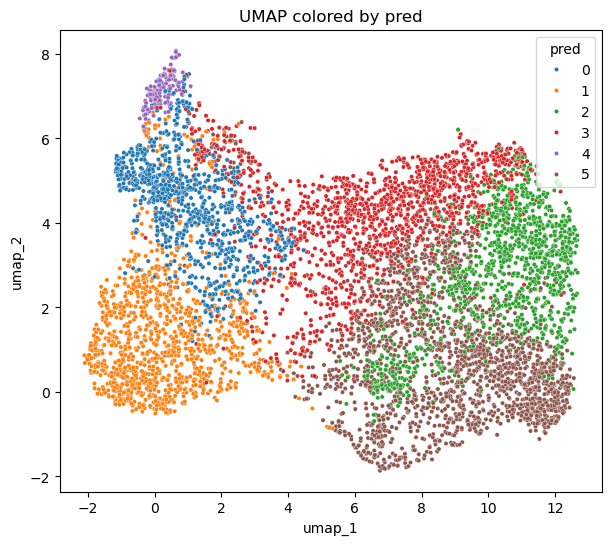

In [173]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 6))
sns.scatterplot(
    data=umap_nt,
    x='umap_1',
    y='umap_2',
    hue='pred',
    s=10,
    palette='tab10'
)

plt.title('UMAP colored by pred')
plt.legend(title='pred')
plt.show()